Upload data

In [1]:
from google.colab import files
upload = files.upload()

Saving Test.csv to Test.csv
Saving Train.csv to Train.csv


Import libraries and define dataframes

In [2]:
import pandas as pd
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

In [3]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Exploring the dataset

In [4]:
# Check data shapes for train and test
train.shape, test.shape

((8523, 12), (5681, 11))

In [9]:
# Check for missing values in both datafames
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [10]:
test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

Item_Weight and Outlet_Size have null values in their columns

In [11]:
# Check for number of unique values and data types in each column for both dataframes
for i in train.columns:
  print(f"{i} : {train[i].nunique()}")

Item_Identifier : 1559
Item_Weight : 415
Item_Fat_Content : 5
Item_Visibility : 7880
Item_Type : 16
Item_MRP : 5938
Outlet_Identifier : 10
Outlet_Establishment_Year : 9
Outlet_Size : 3
Outlet_Location_Type : 3
Outlet_Type : 4
Item_Outlet_Sales : 3493


In [12]:
for i in test.columns:
  print(f"{i} : {test[i].nunique()}")

Item_Identifier : 1543
Item_Weight : 410
Item_Fat_Content : 5
Item_Visibility : 5277
Item_Type : 16
Item_MRP : 4402
Outlet_Identifier : 10
Outlet_Establishment_Year : 9
Outlet_Size : 3
Outlet_Location_Type : 3
Outlet_Type : 4


In [13]:
for i in train.columns:
  print(f"{i} : {train[i].dtype}")


Item_Identifier : object
Item_Weight : float64
Item_Fat_Content : object
Item_Visibility : float64
Item_Type : object
Item_MRP : float64
Outlet_Identifier : object
Outlet_Establishment_Year : int64
Outlet_Size : object
Outlet_Location_Type : object
Outlet_Type : object
Item_Outlet_Sales : float64


In [14]:
for i in test.columns:
  print(f"{i} : {test[i].dtype}")


Item_Identifier : object
Item_Weight : float64
Item_Fat_Content : object
Item_Visibility : float64
Item_Type : object
Item_MRP : float64
Outlet_Identifier : object
Outlet_Establishment_Year : int64
Outlet_Size : object
Outlet_Location_Type : object
Outlet_Type : object


So, we got some categorical columns as well as numerical columns. Before moving on, let’s create two lists. One list with the column names of all the categorical columns and the other list with the column names of all the numerical columns.

In [15]:
cat_columns = []
num_columns = []
for i in train.columns:
  if train[i].dtype == object:
    cat_columns.append(i)
  else:
    num_columns.append(i)

In [16]:
cat_columns


['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [17]:
num_columns

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

Data Preprocessing

In [18]:
# Handling missing values (fill the null values with mean value in "Item_Weight") (fill the null values with the mode value for "Outlet_Size")
train['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)
test['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)

In [19]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [20]:
test.isnull().sum()


Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [21]:
train['Outlet_Size'].mode()[0]


'Medium'

In [22]:
train['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0], inplace=True)
test['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0], inplace=True)

In [23]:
train.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [24]:
test.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

Visualizing Categorical Columns

In [25]:
train[cat_columns].head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


In [26]:
train[cat_columns].nunique()

Item_Identifier         1559
Item_Fat_Content           5
Item_Type                 16
Outlet_Identifier         10
Outlet_Size                3
Outlet_Location_Type       3
Outlet_Type                4
dtype: int64

Import visualization libraries

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
train['Item_Fat_Content'].value_counts()


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

<Axes: xlabel='Item_Fat_Content', ylabel='count'>

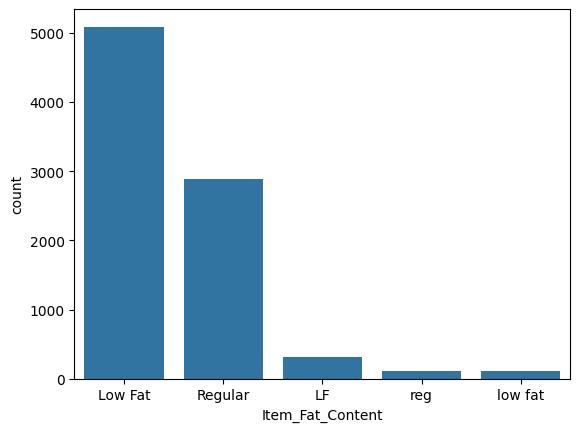

In [31]:
sns.barplot(train['Item_Fat_Content'].value_counts())

After seeing this I realized “LF”, “low fat” and “Low Fat” are all the same, and “reg” and “Regular” are the same.

So, there should be only 2 unique values in this column. Let’s correct this column by replacing both “LF” and “low fat” with “Low Fat” and “reg” with “Regular”.

In [32]:
train['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}, inplace=True)
test['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}, inplace=True)

In [33]:
train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [34]:
test['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    3668
Regular    2013
Name: count, dtype: int64

<Axes: xlabel='Item_Fat_Content', ylabel='count'>

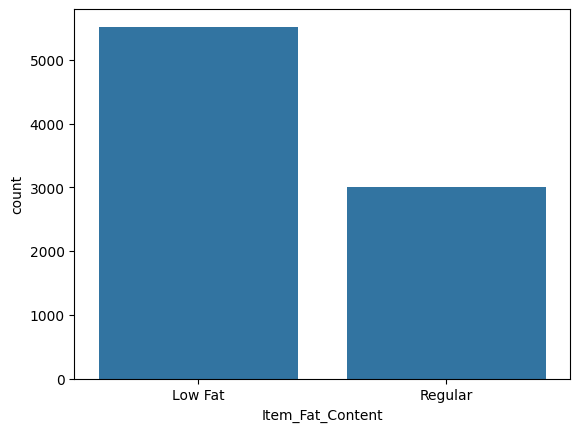

In [35]:
sns.barplot(train['Item_Fat_Content'].value_counts())

<Axes: xlabel='Outlet_Type', ylabel='count'>

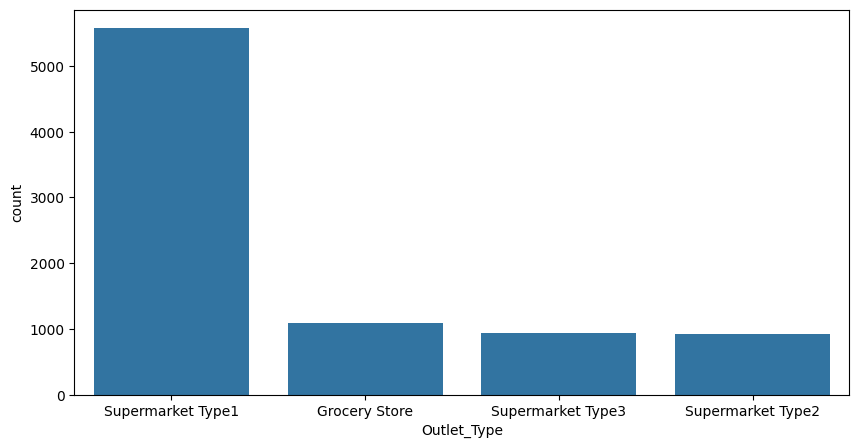

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(train['Outlet_Type'].value_counts())

<Axes: xlabel='Outlet_Location_Type', ylabel='count'>

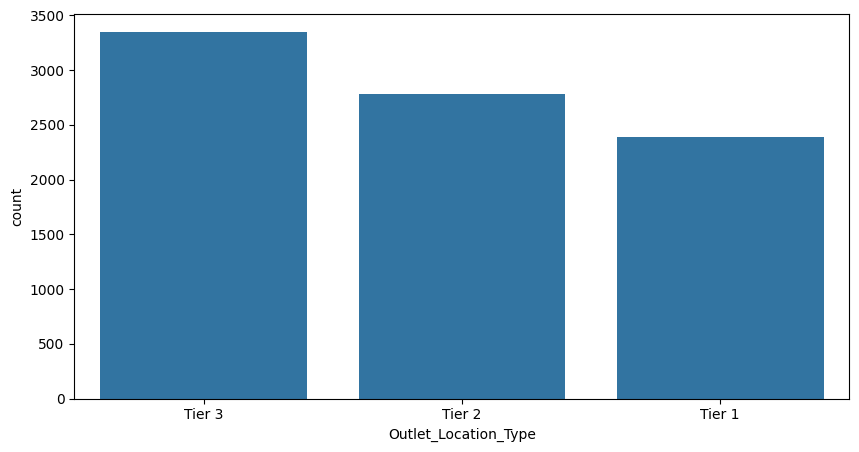

In [37]:
plt.figure(figsize=(10, 5))
sns.barplot(train['Outlet_Location_Type'].value_counts())

<Axes: xlabel='Item_Type', ylabel='count'>

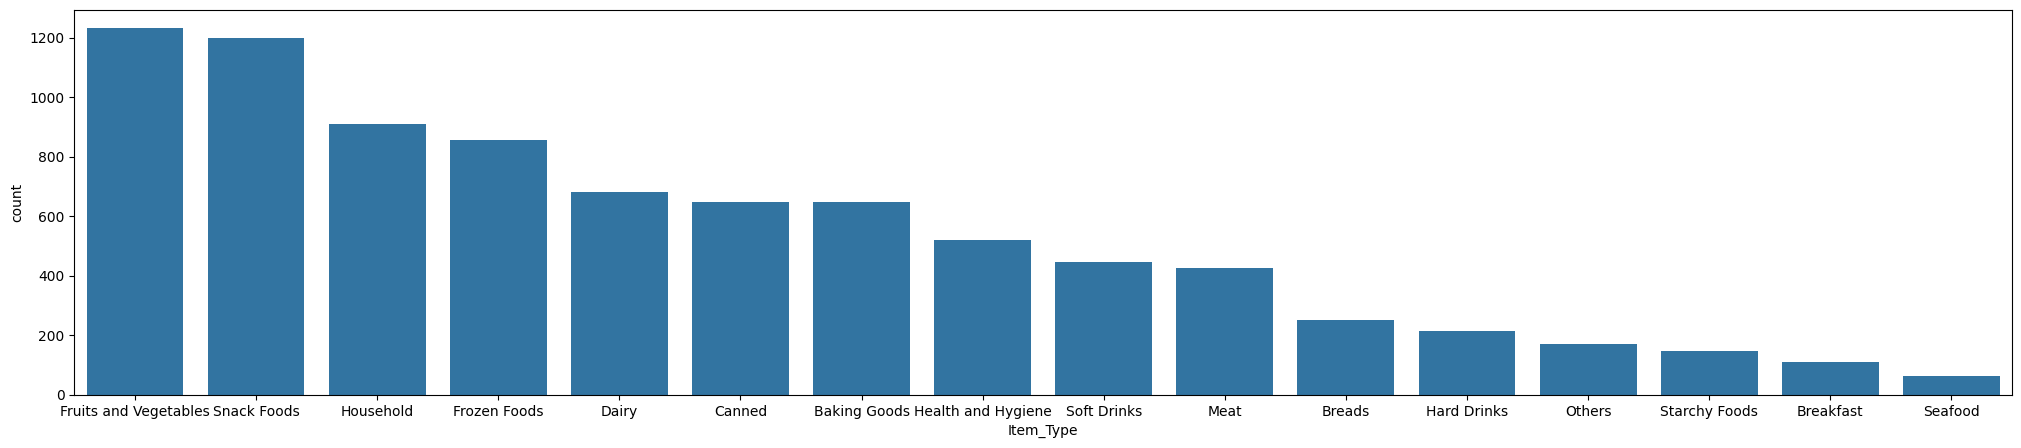

In [38]:
plt.figure(figsize=(25, 5))
sns.barplot(train['Item_Type'].value_counts())

<Axes: xlabel='Outlet_Identifier', ylabel='count'>

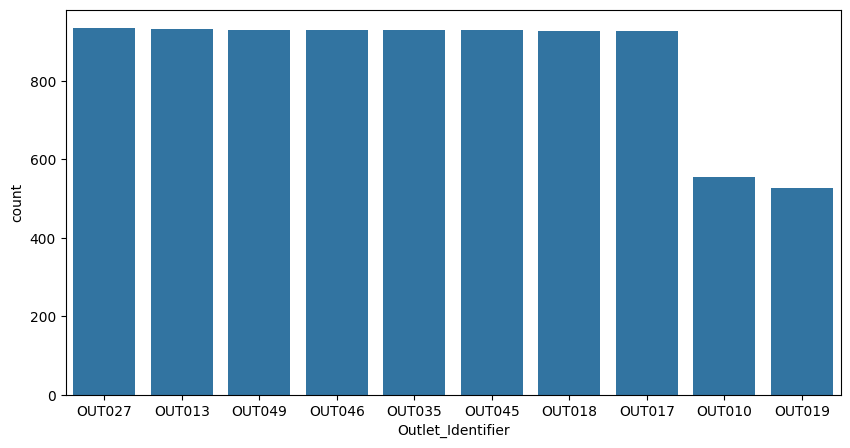

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(train['Outlet_Identifier'].value_counts())

<Axes: xlabel='Outlet_Size', ylabel='count'>

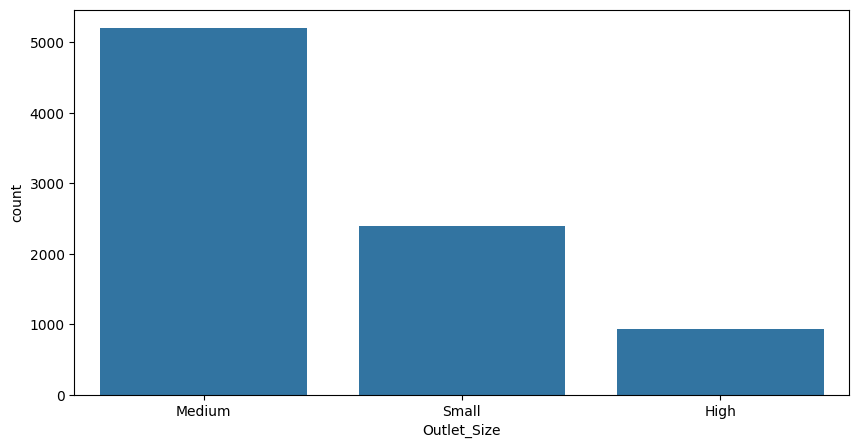

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(train['Outlet_Size'].value_counts())

Visualizing Numerical Columns

In [41]:
train[num_columns]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.300,0.016047,249.8092,1999,3735.1380
1,5.920,0.019278,48.2692,2009,443.4228
2,17.500,0.016760,141.6180,1999,2097.2700
3,19.200,0.000000,182.0950,1998,732.3800
4,8.930,0.000000,53.8614,1987,994.7052
...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,2778.3834
8519,8.380,0.046982,108.1570,2002,549.2850
8520,10.600,0.035186,85.1224,2004,1193.1136
8521,7.210,0.145221,103.1332,2009,1845.5976


<Axes: xlabel='Item_Weight', ylabel='Count'>

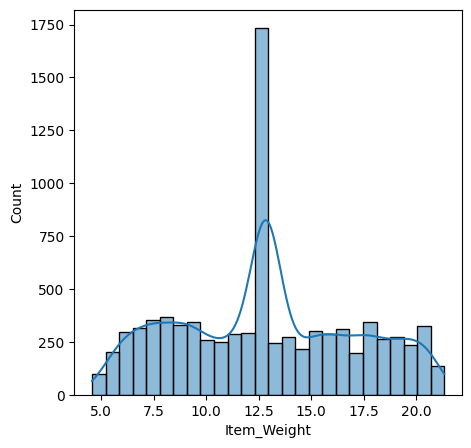

In [42]:
plt.figure(figsize=(5, 5))
sns.histplot(train['Item_Weight'], kde=True)

<Axes: xlabel='Item_Visibility', ylabel='Count'>

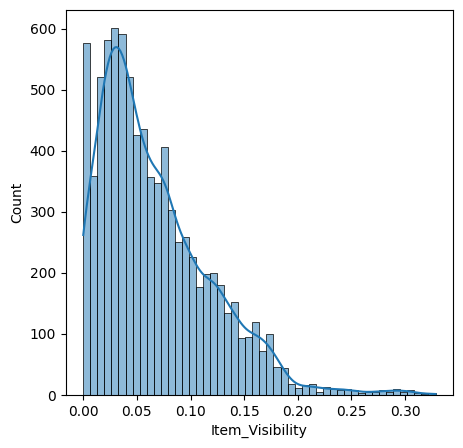

In [43]:
plt.figure(figsize=(5, 5))
sns.histplot(train['Item_Visibility'], kde=True)

<Axes: xlabel='Item_MRP', ylabel='Count'>

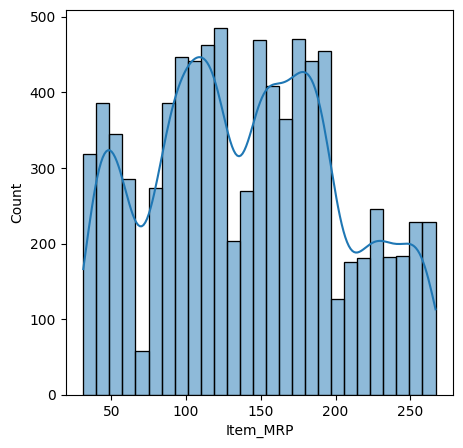

In [44]:
plt.figure(figsize=(5, 5))
sns.histplot(train['Item_MRP'], kde=True)

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

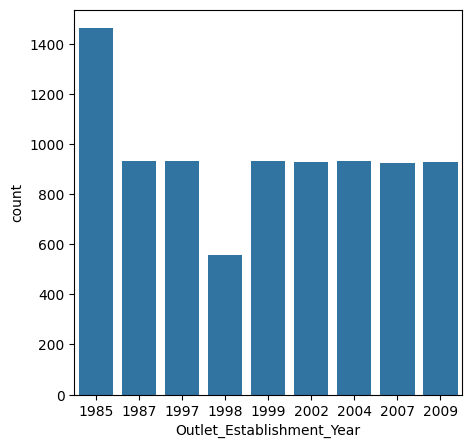

In [45]:
plt.figure(figsize=(5, 5))
sns.countplot(x='Outlet_Establishment_Year', data=train)

<Axes: xlabel='Item_Outlet_Sales', ylabel='Count'>

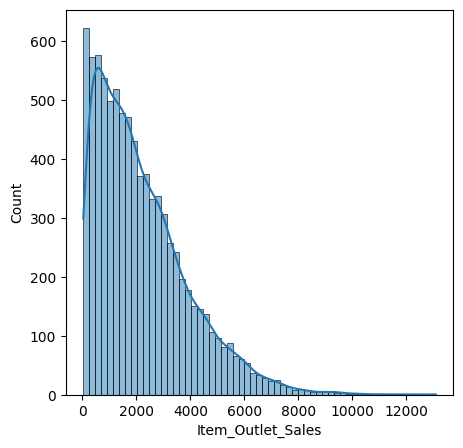

In [46]:
plt.figure(figsize=(5, 5))
sns.histplot(train['Item_Outlet_Sales'], kde=True)

Handling Categorical Values

In [47]:
train[cat_columns].nunique()

Item_Identifier         1559
Item_Fat_Content           2
Item_Type                 16
Outlet_Identifier         10
Outlet_Size                3
Outlet_Location_Type       3
Outlet_Type                4
dtype: int64

In [48]:
train[cat_columns]

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
8518,FDF22,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8519,FDS36,Regular,Baking Goods,OUT045,Medium,Tier 2,Supermarket Type1
8520,NCJ29,Low Fat,Health and Hygiene,OUT035,Small,Tier 2,Supermarket Type1
8521,FDN46,Regular,Snack Foods,OUT018,Medium,Tier 3,Supermarket Type2


Notice the “Item_Identifier”. I think I should only take the first two characters from that, for example, Instead of “FDA15” I am going to change it to just “FD” which means Food. Similarly, Instead of “DRC01" I am going to change it to just ‘DR” which means Drinks.

In [49]:
train['Item_Identifier'] = train['Item_Identifier'].str[:2]
test['Item_Identifier'] = test['Item_Identifier'].str[:2]

In [50]:
train[cat_columns].nunique()


Item_Identifier          3
Item_Fat_Content         2
Item_Type               16
Outlet_Identifier       10
Outlet_Size              3
Outlet_Location_Type     3
Outlet_Type              4
dtype: int64

In [51]:
train[cat_columns].head()


,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FD,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DR,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FD,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FD,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
4,NC,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


I am going to separate the categorical columns into two different categories. As you can see from the above output, we got 7 categorical columns in which 3 columns are ordinal (which means they have a certain order. For example, if you take grade, we know A is first, B is second, and C is third it’s an order those types of columns are also knowns as ordinal columns).

The ordinal columns are ‘Item_Fat_Content’, ‘Outlet_Size’, and ‘Outlet_Location_Type’. The rest of the columns are nominal columns because they don’t any ordering in them.

I am going to apply the Ordinal Encoder technique to ordinal categorical columns. And One-Hot Encoding for nominal categorical columns. Below is the code.

In [52]:
ordinal_cat_columns = ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type']
nominal_cat_columns = ['Item_Identifier', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type']

In [53]:
# One-Hot Encoding using get_dummies()
train = pd.get_dummies(train, columns=nominal_cat_columns)
test = pd.get_dummies(test, columns=nominal_cat_columns)

In [54]:
from sklearn.preprocessing import OrdinalEncoder

# Initialize the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Define the ordinal columns
ordinal_cols = ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type']

# Fit and transform the ordinal columns
train[ordinal_cols] = ordinal_encoder.fit_transform(train[ordinal_cols])
test[ordinal_cols] = ordinal_encoder.fit_transform(test[ordinal_cols])

In [55]:
train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Item_Identifier_DR,Item_Identifier_FD,...,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.0,0.016047,249.8092,1999,1.0,0.0,3735.1380,False,True,...,False,False,False,False,False,True,False,True,False,False
1,5.92,1.0,0.019278,48.2692,2009,1.0,2.0,443.4228,True,False,...,False,False,False,False,False,False,False,False,True,False
2,17.50,0.0,0.016760,141.6180,1999,1.0,0.0,2097.2700,False,True,...,False,False,False,False,False,True,False,True,False,False
3,19.20,1.0,0.000000,182.0950,1998,1.0,2.0,732.3800,False,True,...,False,False,False,False,False,False,True,False,False,False
4,8.93,0.0,0.000000,53.8614,1987,0.0,2.0,994.7052,False,False,...,False,False,False,False,False,False,False,True,False,False


Splitting Features and Label

In [56]:
y = train['Item_Outlet_Sales']
X = train.drop(columns=['Item_Outlet_Sales'])

# The “Item_Outlet_Sales” is the label column that we want to predict

Train and Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=786)

Model Building

In [58]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)
model_prediction = model.predict(X_test)

'''Our model is ready and we have also made the prediction using the model which is stored in model_prediction variable \n
Let’s use the prediction and compare it with the original value and evaluate our model performance using different metrics'''

Model Evaluation

Mean Absolute Error
Mean Squared Error
R2 Score



In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model_r2_score = r2_score(y_test, model_prediction)
model_mae_score = mean_absolute_error(y_test, model_prediction)
model_mse_score = mean_squared_error(y_test, model_prediction)

print(f"R2 Score: {model_r2_score:.2f}")
print(f"MAE Score: {model_mae_score:.2f}")
print(f"MSE Score: {model_mse_score:.2f}")

R2 Score: 0.48
MAE Score: 816.07
MSE Score: 1423839.11
